## Imports

In [1]:
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay

from titanic.data import load_processed_data
from titanic.selection import select_model_features
from titanic.explainability import (
    load_model_bundle,
    get_train_test_from_model_df,
    compute_permutation_importance,
    get_prediction_errors,
    print_classification_summary,
)

- **Permutation importance** : quelles variables comptent vraiment pour le score.
- **PDP** : relation moyenne entre une variable et la probabilité de survie.
- **ICE** : relation individuelle, passager par passager.
- **SHAP** : contribution de chaque variable à une prédiction.
- **Erreur** analysis : où le modèle se trompe.

### Comment fonctionnent les PDP et ICE ?

Les graphiques de **Partial Dependence (PDP)** et **Individual Conditional Expectation (ICE)** permettent d'interpréter un modèle déjà entraîné.

L'idée consiste à prendre les observations réelles du dataset, puis à faire varier artificiellement une seule variable tout en conservant toutes les autres constantes. Pour chaque nouvelle valeur, le modèle calcule une nouvelle prédiction.

Par exemple, pour étudier l'effet de l'âge, on peut prendre un passager donné et remplacer son âge par 5, 10, 15, ..., 60 ans. Le modèle prédit alors la probabilité de survie associée à chacune de ces situations hypothétiques. La courbe obtenue correspond à une **ICE curve**.

Les **ICE plots** représentent ces courbes individuelles pour plusieurs passagers. Ils permettent d'observer si une variable influence tous les individus de la même manière ou si son effet dépend du contexte.

Le **PDP** (courbe pointillée) est simplement la moyenne de toutes les courbes ICE. Il montre l'effet moyen d'une variable sur les prédictions du modèle.

Ces méthodes n'étudient pas directement la réalité historique du Titanic, mais le comportement du modèle entraîné. Elles répondent à la question :

> *"Comment le modèle réagit-il lorsque je modifie cette variable ?"*

et non :

> *"Que se serait-il réellement passé si cette personne avait eu un autre âge ou un autre billet ?"*

Les petits traits noirs situés sous les graphiques (*rug plot*) indiquent les zones où des observations réelles sont présentes dans le dataset. Les interprétations sont généralement plus fiables dans ces régions que dans les zones où peu de données sont disponibles.

## Data and model loading

In [2]:
df = load_processed_data()

df_model = select_model_features(
    df,
    include_target=True
)

bundle = load_model_bundle("../models/model.joblib")

pipeline = bundle["pipeline"]
features = bundle["features"]

df_model = df_model[["Survived"] + features]

print(df_model.shape)
df_model.head()

(1309, 11)


,Survived,Pclass,Title,HasNickname,AgeETR,IsChild,IsAlone,FamilySurvivalRate,FarePerPerson_log1p,TicketSurvivalRate,HasCabin
PassengerId,,,,,,,,,,,
1,0.0,3,Mr,0,22.0,0,0,0.319865,1.531476,0.383838,0
2,1.0,1,Mrs,1,38.0,0,0,0.383838,3.601186,0.383838,1
3,1.0,3,Miss,0,26.0,0,1,0.383838,1.292441,0.383838,0
4,1.0,1,Mrs,1,35.0,0,0,0.319865,3.316003,0.319865,1
5,0.0,3,Mr,0,35.0,0,1,0.486532,2.202765,0.383838,0


## Split train/test

In [3]:
X_train, y_train, X_test = get_train_test_from_model_df(
    df_model,
    target="Survived"
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (891, 10)
y_train: (891,)
X_test: (418, 10)


## Résumé des performances sur train

In [4]:
print_classification_summary(
    pipeline,
    X_train,
    y_train
)

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       549
           1       0.88      0.78      0.83       342

    accuracy                           0.88       891
   macro avg       0.88      0.86      0.87       891
weighted avg       0.88      0.88      0.87       891


Confusion matrix:
[[514  35]
 [ 75 267]]


## Permutation importance

quelles variables comptent vraiment pour le score ?

In [5]:
perm_importance = compute_permutation_importance(
    pipeline=pipeline,
    X=X_train,
    y=y_train,
    scoring="accuracy",
    n_repeats=30,
    random_state=42,
)

perm_importance

,feature,importance_mean,importance_std
0,Title,0.250468,0.014347
1,TicketSurvivalRate,0.073737,0.007205
2,FamilySurvivalRate,0.027834,0.006404
3,Pclass,0.025065,0.003600
4,FarePerPerson_log1p,0.012832,0.005488
5,AgeETR,0.008605,0.003977
6,HasCabin,0.008455,0.001780
7,HasNickname,0.007482,0.002739
8,IsAlone,0.000412,0.002534
9,IsChild,0.000262,0.000627


## Graphique permutation importance

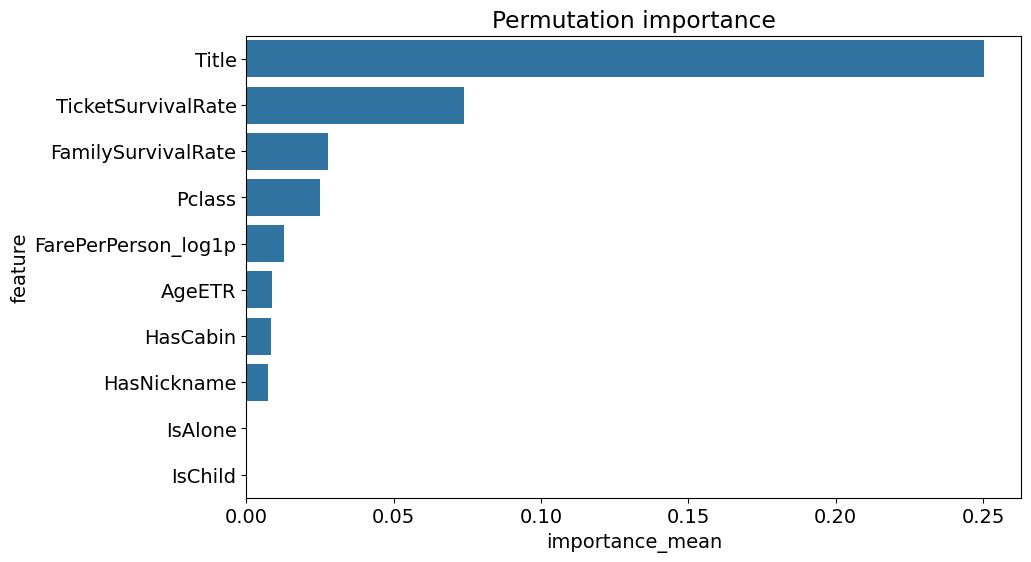

In [6]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=perm_importance.head(15),
    x="importance_mean",
    y="feature"
)

plt.title("Permutation importance")
plt.show()

## Partial Dependence Plot (PDP)

relation moyenne entre une variable et la probabilité de survie

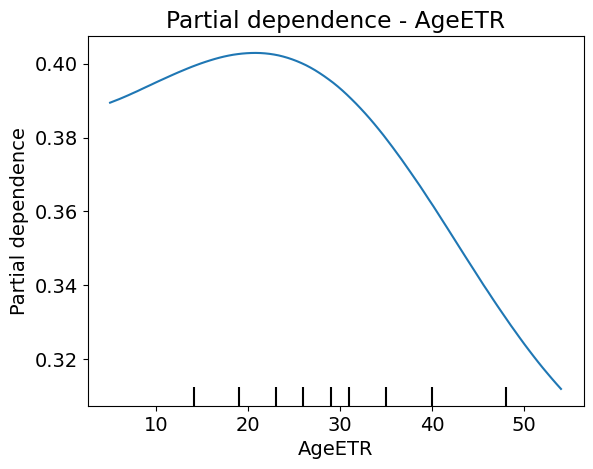

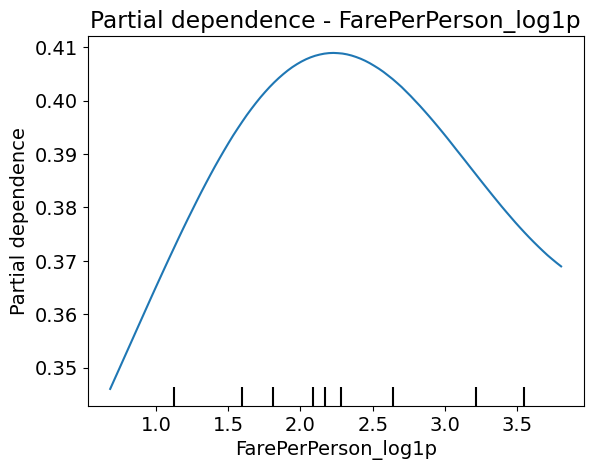

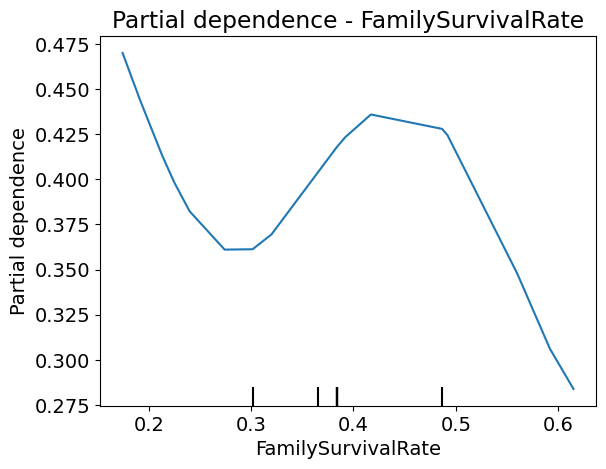

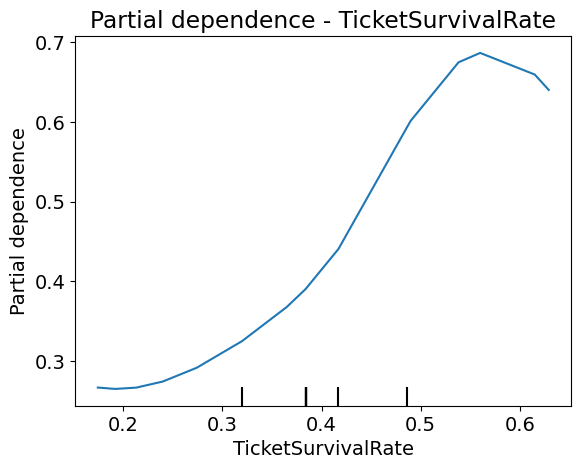

In [7]:
features_to_plot = [
    "AgeETR",
    "FarePerPerson_log1p",
    "FamilySurvivalRate",
    "TicketSurvivalRate",
]

for feature in features_to_plot:
    PartialDependenceDisplay.from_estimator(
        pipeline,
        X_train,
        features=[feature],
        kind="average"
    )
    plt.title(f"Partial dependence - {feature}")
    plt.show()

## ICE plots

relation individuelle, passager par passager

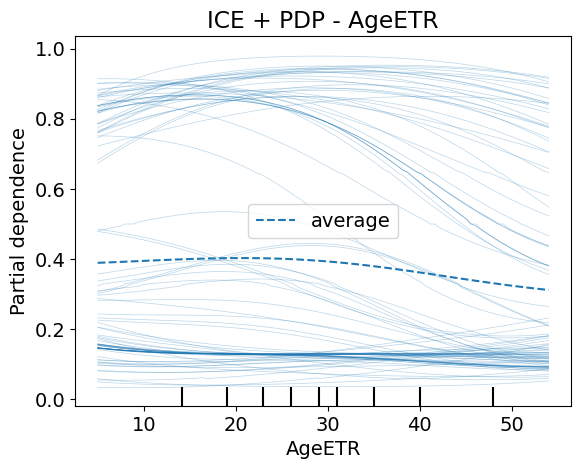

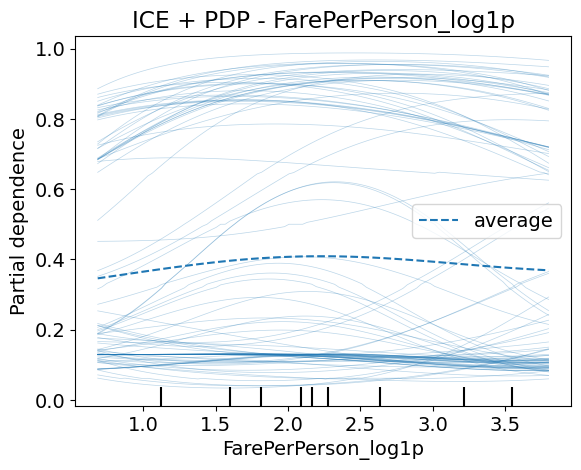

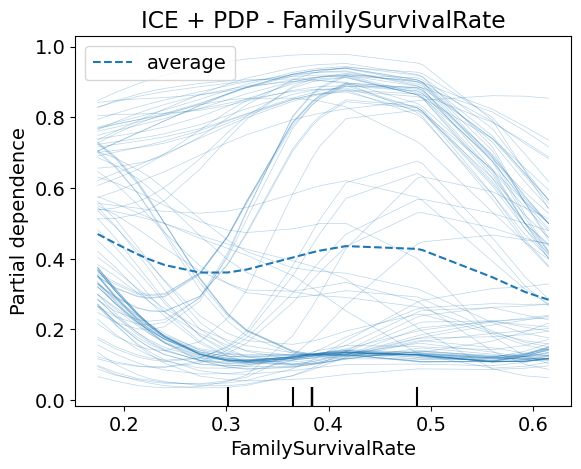

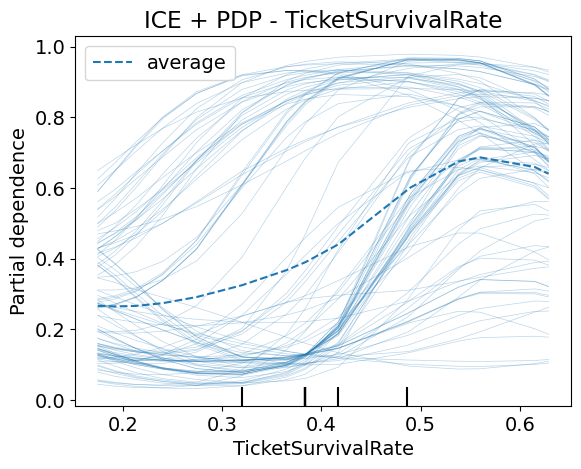

In [8]:
for feature in features_to_plot:
    PartialDependenceDisplay.from_estimator(
        pipeline,
        X_train,
        features=[feature],
        kind="both",
        subsample=100,
        random_state=42
    )
    plt.title(f"ICE + PDP - {feature}")
    plt.show()

## Analyse des erreurs

où le modèle se trompe

In [9]:
errors_df = get_prediction_errors(
    pipeline,
    X_train,
    y_train
)

errors_df["is_error"].value_counts(normalize=True)

is_error
False    0.876543
True     0.123457
Name: proportion, dtype: float64

## Profils mal prédits

In [10]:
errors_df[errors_df["is_error"]].head(20)

,Pclass,Title,HasNickname,AgeETR,IsChild,IsAlone,FamilySurvivalRate,FarePerPerson_log1p,TicketSurvivalRate,HasCabin,y_true,y_pred,is_error,survival_probability
PassengerId,,,,,,,,,,,,,,
15,3,Miss,0,14.000000,0,1,0.383838,1.594751,0.383838,0,0,1,True,0.867301
22,2,Mr,0,34.000000,0,1,0.383838,2.639057,0.383838,1,1,0,True,0.274314
24,1,Mr,0,28.000000,0,1,0.383838,3.597312,0.383838,1,1,0,True,0.297570
37,3,Mr,0,26.725834,0,1,0.383838,2.107689,0.383838,0,1,0,True,0.127514
41,3,Mrs,1,40.000000,0,0,0.383838,1.747024,0.383838,0,0,1,True,0.633432
42,2,Mrs,1,27.000000,0,0,0.319865,2.442347,0.319865,0,0,1,True,0.866381
56,1,Mr,0,44.826231,0,1,0.383838,2.931194,0.383838,1,1,0,True,0.287046
69,3,Miss,0,17.000000,0,0,0.224553,0.757128,0.383838,0,1,0,True,0.180179
82,3,Mr,0,29.000000,0,1,0.383838,1.064711,0.383838,0,1,0,True,0.129615


## Comparaison erreurs vs bonnes prédictions

In [11]:
errors_df.groupby("is_error")[
    [
        "AgeETR",
        "FarePerPerson_log1p",
        "FamilySurvivalRate",
        "TicketSurvivalRate",
        "IsAlone",
        "HasCabin",
    ]
].mean()

,AgeETR,FarePerPerson_log1p,FamilySurvivalRate,TicketSurvivalRate,IsAlone,HasCabin
is_error,,,,,,
False,29.414018,2.252308,0.381774,0.391246,0.592830,0.220230
True,31.258570,2.285565,0.386752,0.392356,0.672727,0.290909


## SHAP setup

contribution de chaque variable à une prédiction

In [19]:
import shap

from titanic.explainability import (
    compute_shap_kernel_explainer,
    compute_shap_values,
)

X_background = X_train
X_explain = X_train

explainer = compute_shap_kernel_explainer(
    pipeline,
    X_background
)

## Calcul SHAP

In [20]:
shap_values = compute_shap_values(
    explainer,
    X_explain,
    nsamples=100
)

100%|██████████| 891/891 [01:32<00:00,  9.62it/s]


## SHAP summary plot

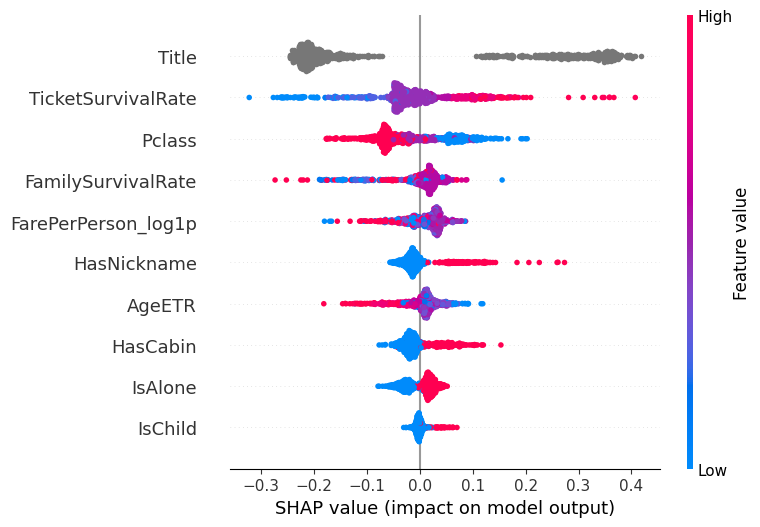

In [21]:
shap.summary_plot(
    shap_values,
    X_explain
)

- **importance** est donnée par l’ordre des lignes : plus haut = plus important
- **amplitude** : étalement horizontale. Plus une variable a une grande amplitude, plus la probabilité peut varier : quand cette variable change, la prédiction change beaucoup
- chaque ligne = 1 variable
- chaque point représente un passager
- l’axe horizontale représente l’impact sur la prédiction (gauche en - pousse vers la mort, droite en + pousse vers la survie)
- couleur indique la valeur de la variable : bleu=faible ; rouge=élevé
    - attention, pour les variables catégorielles qui ont été recodé avec des numéros, les couleurs n’ont pas vraiment de sens

##### Interprétation
- Title
    - *Mrs*, *Miss*, *Master* survivent beaucoup plus que *Mr*
- TicketSurvivalRate
    - faible TicketSurvivalRate (bleu) ← fortement négatif
    - fort TicketSurvivalRate (rouge) → fortement positif
- Pclass
    - 1 = première classe ; 3 = troisième classe, donc : rouge = Pclass élevé = pauvre


## Explication locale (pour un passager)

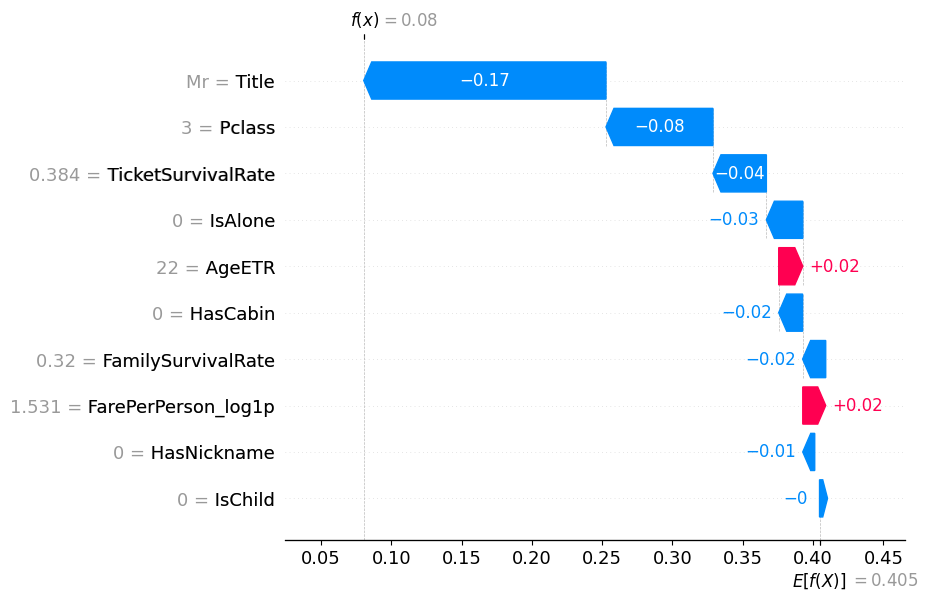

In [25]:
i = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_explain.iloc[i],
        feature_names=X_explain.columns
    )
)

- explication locale : on explique une seule prédiction, pour un seul passager
- f(x) = 0.08 : pour ce passager, le modèle estime environ 8% de probabilité de survie.
- valeur de base : 0.4 environ, on part de là et ensuite les variables vont pousser la prédiction vers le décès ou vers la survie
    - Title = Mr : moins de chance de survie (cf. gros bloc bleu)
    - Pclass = 3 : moins de chance de survie
    - etc.
- deux éléments positifs : FarePerPerson et AgeETR
    - 22 ans : le modèle considère que c’est légèrement favorable pour la survie
- mais ces effets sont minuscules comparés aux effets négatifs